In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
ds_X = sg.load_dataset("../human_ref_zarr_20x_inds/Gorilla_gorilla_ssp/zarr_X")
ds_X.contig_id.values

array(['NC_060925.1', 'NC_060926.1', 'NC_060927.1', 'NC_060928.1',
       'NC_060929.1', 'NC_060930.1', 'NC_060931.1', 'NC_060932.1',
       'NC_060933.1', 'NC_060934.1', 'NC_060935.1', 'NC_060936.1',
       'NC_060937.1', 'NC_060938.1', 'NC_060939.1', 'NC_060940.1',
       'NC_060941.1', 'NC_060942.1', 'NC_060943.1', 'NC_060944.1',
       'NC_060945.1', 'NC_060946.1', 'NC_060947.1', 'NC_060948.1'],
      dtype=object)

In [3]:
contig_IDs = pd.Series(ds_X.contig_id[22:23].values).map(dict(zip(ds_X.contig_id.values, range(len(ds_X.contig_id.values))))).values
contig_IDs

array([22])

In [4]:
pd.value_counts(ds_X.variant_contig[:].values)

/tmp/23514931/ipykernel_2032093/3042891855.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(ds_X.variant_contig[:].values)


22    784102
23       774
8        111
2        105
1         95
10        93
6         57
5         56
18        46
15        46
3         40
14        19
13        17
4         16
0         15
21         7
12         6
9          1
Name: count, dtype: int64

In [5]:
ds = sg.load_dataset("../human_ref_zarr_20x_inds/Gorilla_gorilla_ssp/zarr")
pd.value_counts(ds.variant_contig[:].values)

/tmp/23514931/ipykernel_2032093/556968443.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(ds.variant_contig[:].values)


2     1919349
3     1728453
5     1702473
1     1439215
10    1277856
6     1216397
4     1116043
7      952721
12     934537
11     893247
9      870950
14     716251
8      715168
15     702247
17     646211
13     622019
19     604666
18     570484
20     389371
21     350379
0      213244
16     206590
22       2034
23       1755
Name: count, dtype: int64

In [6]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              #& (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                              #& (metadata_table.genus == "Gorilla")
                             ]

In [7]:
df_het = pd.read_csv("../results/window_stats_20x_inds/Gorilla_gorilla_ssp_100kb_het_hom.txt", sep="\t")
df_het

,het,alt_hom,variant_count,GVCF_ID,window_start,chrom,window_end,callable_frac,chr_type,species
0,7.0,10,79,SAMEA5204233,0,NC_073224.2,100000,0.00895,aut,Gorilla_gorilla_ssp
1,0.0,0,0,SAMEA5204233,100000,NC_073224.2,200000,0.00000,aut,Gorilla_gorilla_ssp
2,0.0,0,0,SAMEA5204233,200000,NC_073224.2,300000,0.00000,aut,Gorilla_gorilla_ssp
3,11.0,33,495,SAMEA5204233,300000,NC_073224.2,400000,0.12119,aut,Gorilla_gorilla_ssp
4,0.0,0,0,SAMEA5204233,400000,NC_073224.2,500000,0.00000,aut,Gorilla_gorilla_ssp
...,...,...,...,...,...,...,...,...,...,...
1008731,0.0,0,7,SAMEA2446072,177100000,NC_073247.2,177200000,0.00380,chrX,Gorilla_gorilla_ssp
1008732,12.0,0,453,SAMEA2446072,177200000,NC_073247.2,177300000,0.20170,chrX,Gorilla_gorilla_ssp
1008733,15.0,0,665,SAMEA2446072,177300000,NC_073247.2,177400000,0.32752,chrX,Gorilla_gorilla_ssp
1008734,7.0,2,656,SAMEA2446072,177400000,NC_073247.2,177500000,0.36726,chrX,Gorilla_gorilla_ssp


In [8]:
callable_x = df_het.loc[(df_het.callable_frac >= 0.75) & (df_het.chr_type == "chrX")]
callable_x_mean = callable_x.groupby(["window_start"])[["het"]].mean().reset_index()

<Axes: xlabel='window_start', ylabel='het'>

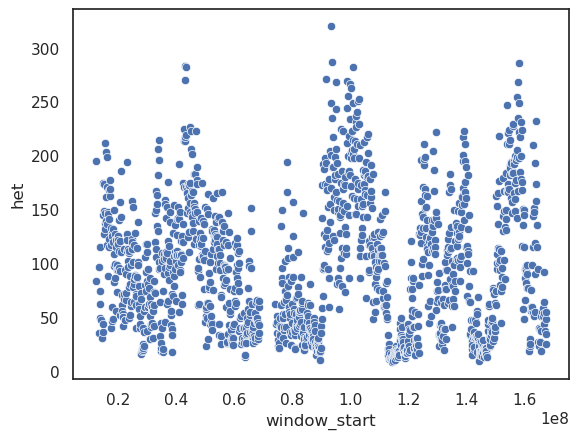

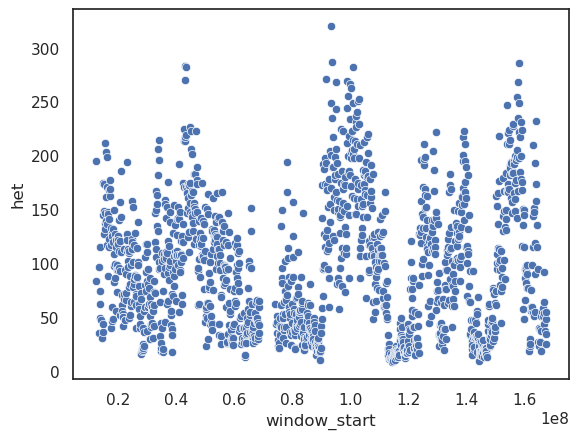

In [9]:
sns.scatterplot(callable_x_mean, x="window_start", y="het")

In [10]:
df_het = pd.read_csv("../results/human_window_stats_20x_inds/Gorilla_gorilla_ssp_100kb_het_hom.txt", sep="\t")
df_het

,het,alt_hom,variant_count,GVCF_ID,window_start,chrom,window_end,callable_frac,chr_type,species
0,0.0,0,0,SAMEA5204233,0,NC_060925.1,100000,0.00000,aut,Gorilla_gorilla_ssp
1,0.0,0,0,SAMEA5204233,100000,NC_060925.1,200000,0.00000,aut,Gorilla_gorilla_ssp
2,3.0,19,88,SAMEA5204233,200000,NC_060925.1,300000,0.00000,aut,Gorilla_gorilla_ssp
3,1.0,3,23,SAMEA5204233,300000,NC_060925.1,400000,0.00000,aut,Gorilla_gorilla_ssp
4,0.0,0,0,SAMEA5204233,400000,NC_060925.1,500000,0.00000,aut,Gorilla_gorilla_ssp
...,...,...,...,...,...,...,...,...,...,...
592510,50.0,69,351,SAMEA2446072,153500000,NC_060947.1,153600000,0.58638,chrX,Gorilla_gorilla_ssp
592511,25.0,6,144,SAMEA2446072,153600000,NC_060947.1,153700000,0.53072,chrX,Gorilla_gorilla_ssp
592512,26.0,17,184,SAMEA2446072,153700000,NC_060947.1,153800000,0.52211,chrX,Gorilla_gorilla_ssp
592513,73.0,14,292,SAMEA2446072,153800000,NC_060947.1,153900000,0.98852,chrX,Gorilla_gorilla_ssp


<Axes: xlabel='window_start', ylabel='het'>

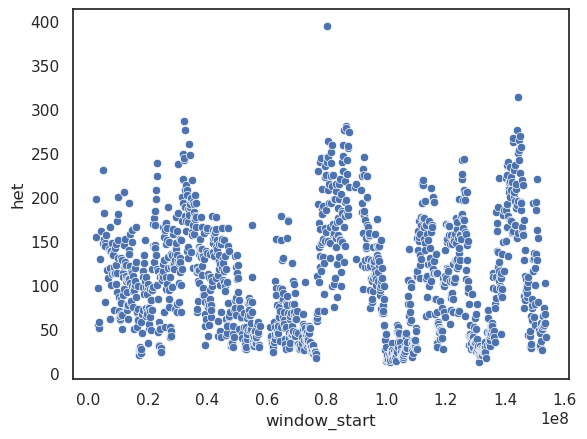

In [11]:
callable_x = df_het.loc[(df_het.callable_frac >= 0.75) & (df_het.chr_type == "chrX")]
callable_x_mean = callable_x.groupby(["window_start"])[["het"]].mean().reset_index()
sns.scatterplot(callable_x_mean, x="window_start", y="het")

In [12]:
df_pi = pd.read_csv("../results/window_stats_20x_inds/Gorilla_gorilla_ssp_100kb_pi_fst0.1.txt", sep="\t")
df_pi

,window_start,chrom,divergence_0,pi_0,window_end,callable_frac,chr_type,species
0,0,NC_073224.2,16.724138,8.603053,100000,0.00895,aut,Gorilla_gorilla_ssp
1,100000,NC_073224.2,0.000000,0.000000,200000,0.00000,aut,Gorilla_gorilla_ssp
2,200000,NC_073224.2,0.000000,0.000000,300000,0.00000,aut,Gorilla_gorilla_ssp
3,300000,NC_073224.2,72.172414,54.271984,400000,0.12119,aut,Gorilla_gorilla_ssp
4,400000,NC_073224.2,0.000000,0.000000,500000,0.00000,aut,Gorilla_gorilla_ssp
...,...,...,...,...,...,...,...,...
34779,177100000,NC_073247.2,0.448276,0.787123,177200000,0.00380,chrX,Gorilla_gorilla_ssp
34780,177200000,NC_073247.2,28.655172,48.117737,177300000,0.20170,chrX,Gorilla_gorilla_ssp
34781,177300000,NC_073247.2,37.931034,61.232657,177400000,0.32752,chrX,Gorilla_gorilla_ssp
34782,177400000,NC_073247.2,38.206897,57.664594,177500000,0.36726,chrX,Gorilla_gorilla_ssp


In [13]:
callable_x_pi = df_pi.loc[(df_pi.callable_frac >= 0.75) & (df_pi.chr_type == "chrX")]

In [14]:
df_het = pd.read_csv("../results/window_stats_20x_inds/Gorilla_gorilla_ssp_100kb_het_hom.txt", sep="\t")
callable_x = df_het.loc[(df_het.callable_frac >= 0.75) & (df_het.chr_type == "chrX")]
callable_x_mean = callable_x.groupby(["window_start"])[["het"]].mean().reset_index()

In [15]:
callable_x_mean["pi"] = callable_x_pi.reset_index().pi_0
callable_x_mean["het/pi"] = callable_x_mean["het"]/callable_x_mean["pi"]

<Axes: xlabel='het/pi', ylabel='Count'>

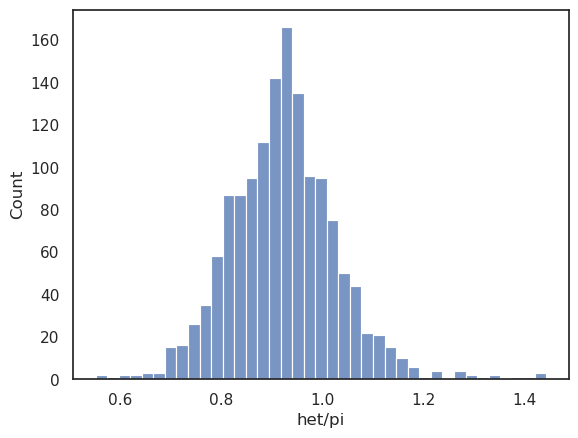

In [16]:
sns.histplot(callable_x_mean, x="het/pi")

<Axes: xlabel='window_start', ylabel='het/pi'>

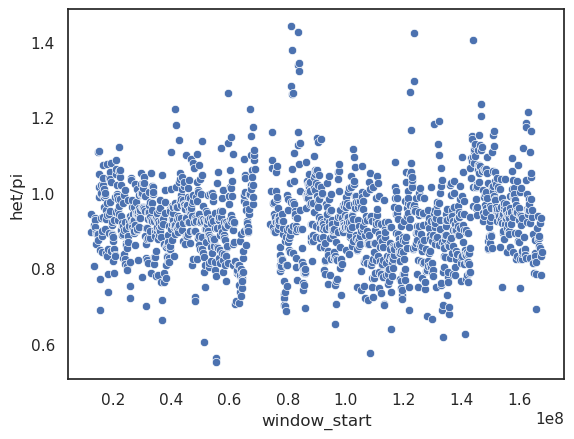

In [17]:
sns.scatterplot(callable_x_mean, x="window_start", y="het/pi")

<Axes: xlabel='het', ylabel='pi'>

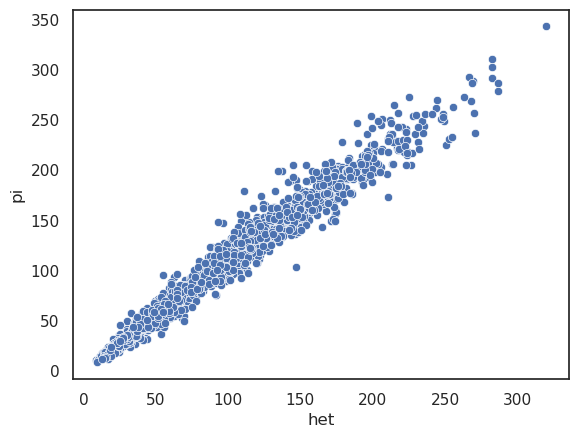

In [18]:
sns.scatterplot(callable_x_mean, x="het", y="pi")

<Axes: xlabel='het', ylabel='het/pi'>

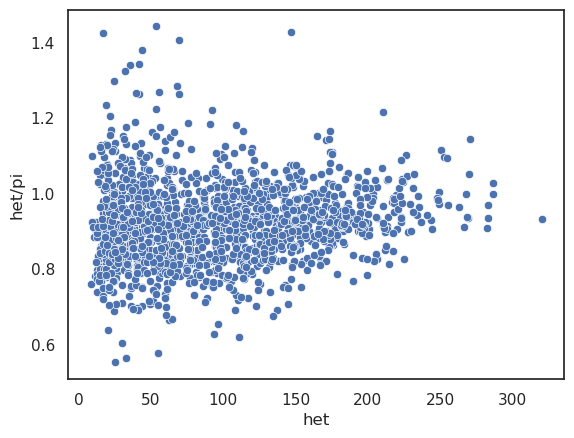

In [19]:
sns.scatterplot(callable_x_mean, x="het", y="het/pi")

In [41]:
# Better implementation, now used for entire genome
df_pi_het = df_pi.merge(df_het.groupby(["chrom", "window_start"])[["het"]].mean().reset_index(), on=["chrom", "window_start"])
df_pi_het["het/pi"] = df_pi_het["het"]/df_pi_het["pi_0"]

<Axes: xlabel='het/pi', ylabel='Proportion'>

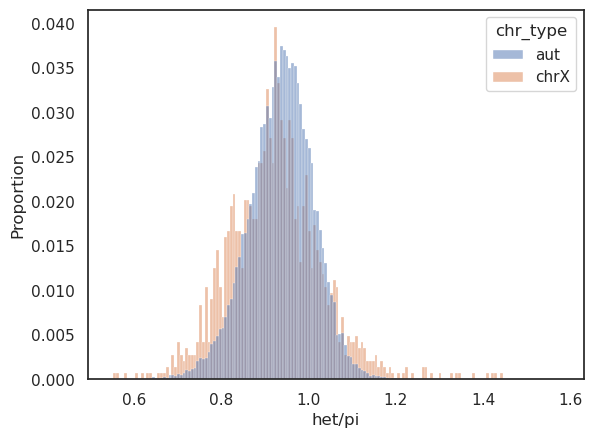

In [46]:
sns.histplot(df_pi_het.loc[df_pi_het.callable_frac >= 0.75], x="het/pi", hue="chr_type", stat="proportion", common_norm=False)

In [47]:
df_pi_het.loc[df_pi_het.callable_frac >= 0.75].groupby(["chr_type"])[["het/pi"]].mean()

,het/pi
chr_type,
aut,0.936337
chrX,0.923719


In [48]:
df_pi = pd.read_csv("../results/window_stats_20x_inds/Macaca_arctoides_ssp_100kb_pi_fst0.1.txt", sep="\t")
df_pi

,window_start,chrom,divergence_0,pi_0,divergence_1,pi_1,divergence_2,pi_2,divergence_3,pi_3,divergence_4,pi_4,divergence_5,pi_5,window_end,callable_frac,chr_type,species
0,0,NC_065578.1,849.5,95.666667,957.5,134.000000,900.0,292.0,1008.0,52.0,914.0,8.0,1034.0,58.0,100000,0.94626,aut,Macaca_arctoides_ssp
1,100000,NC_065578.1,1023.0,81.000000,994.5,255.000000,787.0,187.0,971.0,101.0,926.0,0.0,926.0,156.0,200000,0.96333,aut,Macaca_arctoides_ssp
2,200000,NC_065578.1,891.5,239.166667,890.0,137.500000,788.0,16.0,903.0,1.0,1021.0,5.0,1003.0,75.0,300000,0.91255,aut,Macaca_arctoides_ssp
3,300000,NC_065578.1,899.0,231.833333,977.0,269.166667,737.0,41.0,1021.0,5.0,1001.0,3.0,1006.0,322.0,400000,0.88527,aut,Macaca_arctoides_ssp
4,400000,NC_065578.1,945.0,74.833333,1014.0,214.833333,835.0,141.0,1079.0,7.0,1078.0,0.0,1059.0,107.0,500000,0.94584,aut,Macaca_arctoides_ssp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27970,150200000,NC_065598.1,257.0,4.000000,236.0,20.000000,310.0,2.0,315.0,1.0,160.0,NaN,318.0,22.0,150300000,0.99314,chrX,Macaca_arctoides_ssp
27971,150300000,NC_065598.1,297.5,7.333333,322.0,27.333333,414.0,2.0,421.0,5.0,218.0,NaN,431.0,29.0,150400000,0.94676,chrX,Macaca_arctoides_ssp
27972,150400000,NC_065598.1,262.0,2.000000,246.0,16.000000,314.0,0.0,340.0,2.0,162.0,NaN,341.0,29.0,150500000,0.72763,chrX,Macaca_arctoides_ssp
27973,150500000,NC_065598.1,375.0,11.333333,379.0,33.333333,474.0,2.0,488.0,6.0,257.0,NaN,503.0,35.0,150600000,0.93679,chrX,Macaca_arctoides_ssp


Loading in the genes from Cat/Liftoff Genes for hs1.
https://genome.ucsc.edu/cgi-bin/hgTrackUi?hgsid=2298144658_Clnnokckvrh8JGYnno0LAHKAgcaR&db=hub_3671779_hs1&c=chr9&g=hub_3671779_catLiftOffGenesV1

In [20]:
CAT_Genes = pd.read_csv("../data/hs1_CATGenes.bed", sep="\t")

/tmp/23514931/ipykernel_2032093/4071228108.py:1: DtypeWarning: Columns (23,36) have mixed types. Specify dtype option on import or set low_memory=False.
  CAT_Genes = pd.read_csv("../data/hs1_CATGenes.bed", sep="\t")


In [21]:
CAT_Genes.columns

Index(['#chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand',
       'thickStart', 'thickEnd', 'reserved', 'blockCount', 'blockSizes',
       'chromStarts', 'name2', 'cdsStartStat', 'cdsEndStat', 'exonFrames',
       'txId', 'type', 'geneName', 'geneType', 'sourceGene',
       'sourceTranscript', 'alignmentId', 'alternativeSourceTranscripts',
       'Paralogy', 'UnfilteredParalogy', 'collapsedGeneIds',
       'collapsedGeneNames', 'frameshift', 'exonAnnotationSupport',
       'intronAnnotationSupport', 'transcriptClass', 'transcriptModes',
       'validStart', 'validStop', 'properOrf', 'extra_paralog'],
      dtype='object')

In [22]:
len(CAT_Genes.name2.unique())

60839

In [23]:
CAT_Genes.geneType.unique()

array(['lncRNA', 'processed_pseudogene', 'protein_coding',
       'transcribed_processed_pseudogene',
       'transcribed_unprocessed_pseudogene', 'snRNA',
       'unprocessed_pseudogene', 'miRNA', 'misc_RNA', 'TEC',
       'transcribed_unitary_pseudogene', 'snoRNA', 'scaRNA',
       'rRNA_pseudogene', 'unitary_pseudogene', 'polymorphic_pseudogene',
       'pseudogene', 'StringTie', 'IG_V_pseudogene', 'rRNA', 'scRNA',
       'IG_V_gene', 'IG_C_gene', 'IG_J_gene', 'Mt_tRNA', 'sRNA',
       'ribozyme', 'translated_processed_pseudogene', 'vault_RNA',
       'TR_C_gene', 'TR_J_gene', 'TR_V_gene', 'TR_V_pseudogene',
       'translated_unprocessed_pseudogene', 'IG_C_pseudogene', 'Mt_rRNA',
       'unknown_likely_coding', 'TR_J_pseudogene', 'IG_J_pseudogene',
       'IG_D_gene', 'IG_pseudogene'], dtype=object)

In [24]:
protein_coding = CAT_Genes.loc[CAT_Genes.geneType == "protein_coding"]
protein_coding#.name.unique()

,#chrom,chromStart,chromEnd,name,score,strand,thickStart,thickEnd,reserved,blockCount,...,collapsedGeneNames,frameshift,exonAnnotationSupport,intronAnnotationSupport,transcriptClass,transcriptModes,validStart,validStop,properOrf,extra_paralog
6,chr1,111902,112896,OR4F21-201,0,-,111939,112877,"76,85,212",2,...,"OR4F29,OR4F3",True,"0,0",0,ortholog,transMap,True,True,False,False
98,chr1,353570,368044,SAMD11-203,0,+,354074,368044,"76,85,212",7,...,NaN,NaN,"1,1,1,1,1,1,1","1,1,1,1,1,1",ortholog,transMap,True,False,True,False
99,chr1,354792,364585,SAMD11-204,0,+,355574,364585,"76,85,212",5,...,NaN,NaN,"1,1,1,1,1","1,1,1,1",ortholog,transMap,True,False,True,False
100,chr1,355363,373316,SAMD11-202,0,+,355574,372895,"76,85,212",14,...,NaN,NaN,"1,1,1,1,1,1,1,1,1,1,1,1,1,1","1,1,1,1,1,1,1,2,2,2,2,2,2",ortholog,transMap,True,True,True,False
101,chr1,355373,373323,SAMD11-210,0,+,355574,371440,"76,85,212",13,...,NaN,False,"1,1,1,1,1,1,1,1,1,1,1,1,1","1,1,1,1,1,1,1,2,2,2,2,2",ortholog,transMap,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234887,chr22,51283278,51296783,RABL2B-211,0,-,51296783,51296783,"85,212,76",6,...,NaN,NaN,"1,1,1,1,1,1","2,2,2,2,1",ortholog,transMap,True,True,True,False
234888,chr22,51284706,51297127,RABL2B-202,0,-,51286603,51295791,"76,85,212",6,...,NaN,NaN,"1,1,1,1,1,1","1,2,2,2,1",ortholog,transMap,True,True,True,False
234889,chr22,51289267,51297097,RABL2B-214,0,-,51294202,51295791,"85,212,76",6,...,NaN,NaN,"1,1,1,1,1,1","2,2,1,1,1",ortholog,transMap,True,True,True,False
234890,chr22,51291156,51297127,RABL2B-212,0,-,51297127,51297127,"85,212,76",3,...,NaN,NaN,"1,1,1","2,1",ortholog,transMap,True,True,True,False


In [25]:
len(protein_coding.name2.unique())

21229